<a href="https://colab.research.google.com/github/PercyTechX/GestionyAlmacenamientodeArchivosGDS/blob/main/proyecto_rl_turnos_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Asignación dinámica de turnos en transporte público mediante Aprendizaje por Refuerzo
**Curso:** Aprendizaje por Refuerzo — Maestría MIA UNI · Cuaderno reproducible completo

**Estructura (dos modelos, como el paper):**
- **Parte A — Estudio de formulación (por franjas):** entorno v1, pruebas, y la validación teórica en versión reducida (Programación Dinámica exacta + Q-learning tabular). Resultado heredado: la heurística voraz es *óptima* en pequeño (certificado por DP) y PPO empata con ella.
- **Parte B — Modelo principal (HORARIO):** entorno v2 con tick = 1 hora, flota explícita (8 buses + 2 reservas), 5 eventos (enfermedad, tardanza, avería, pico, retraso) y la **norma SUTRAN codificada en la máscara** (5 h continuas → descanso obligatorio; jornada regular 8 h; tope 10 h). Entrenamiento MaskablePPO, evaluación (Tabla I) y export de trayectorias para la demo.

**Reproducibilidad:** semillas fijas en todo; evaluación con semillas nunca vistas en entrenamiento.

In [1]:
!pip install -q gymnasium stable-baselines3 sb3-contrib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 4.0 MB/s eta 0:00:00


---
## PARTE A · Estudio de formulación (por franjas)
### A.1 — Entorno v1 y pruebas

In [2]:
%%writefile env_turnos.py
# -*- coding: utf-8 -*-
"""
env_turnos.py — Entorno Gymnasium: Asignación dinámica de turnos en transporte público.

Proyecto de curso: Aprendizaje por Refuerzo — Maestría MIA UNI.
Versión del MDP: v0.3 (ver plan_proyecto_rl_turnos.md)

Diseño cerrado en Fase 0:
- 3 rutas (A, B, C), 12 conductores, 8 buses (implícito vía demanda), 3 franjas.
- Episodio = 1 día operativo = 9 ticks de reloj (3 sub-momentos por franja).
- En cada tick el agente puede tomar hasta MAX_DECISIONS_PER_TICK decisiones;
  la acción no-op (o agotar el cupo) cierra el tick.
- Acción compuesta: (tipo, conductor, ruta) con tipo ∈ {RESERVA, MOVER, RELEVO}
  + no-op  →  3*12*3 + 1 = 109 acciones discretas, con máscara de validez.
- Recompensa v0.3: +2 cobertura/tick, −4 hueco/tick, −1.5 hora extra/tick,
  terminal: −0.5·σ(horas)² y +5 si el episodio cierra sin huecos.

Compatible con MaskablePPO (sb3-contrib) vía el método `action_masks()`.
"""

from __future__ import annotations

import json
from dataclasses import dataclass, field

import numpy as np
import gymnasium as gym
from gymnasium import spaces

# ----------------------------------------------------------------------------
# Constantes del problema
# ----------------------------------------------------------------------------
ROUTES = ["A", "B", "C"]
N_ROUTES = len(ROUTES)
N_DRIVERS = 12
SLOTS = ["Mañana", "Mediodía", "Tarde"]
N_SLOTS = len(SLOTS)
TICKS_PER_SLOT = 3
N_TICKS = N_SLOTS * TICKS_PER_SLOT          # 9 ticks de reloj operativo
MAX_DECISIONS_PER_TICK = 3                   # cupo de intervenciones por tick

# Demanda base: unidades requeridas por (ruta, franja)
BASE_DEMAND = np.array([
    [3, 3, 3],   # Ruta A
    [3, 3, 3],   # Ruta B
    [2, 3, 3],   # Ruta C
], dtype=np.int64)

MAX_SLOTS_NORMAL = 2      # franjas sin hora extra; la 3.ª franja es hora extra
MAX_SLOTS_LEGAL = 3       # tope legal duro: ~12 h/24 h (D.S. 017-2009-MTC, SUTRAN)
NO_ASSIGN = -1            # valor "sin ruta" en la matriz de asignación

# Tipos de acción
A_RESERVA, A_MOVER, A_RELEVO = 0, 1, 2
ACTION_TYPES = ["RESERVA", "MOVER", "RELEVO"]
N_TYPED_ACTIONS = 3 * N_DRIVERS * N_ROUTES   # 108
NOOP = N_TYPED_ACTIONS                        # 108 → total 109
N_ACTIONS = N_TYPED_ACTIONS + 1

# Pesos de la recompensa (v0.3)
RW_COVER = 2.0
RW_GAP = -4.0
RW_OVERTIME = -1.5
RW_BALANCE_COEF = -0.5    # multiplicado por sigma^2 al terminar
RW_PERFECT_BONUS = 5.0
RW_INVALID = -1.0         # castigo defensivo (no debería ocurrir con máscara)

# Probabilidades de eventos estocásticos (por episodio, modo aleatorio)
P_ABSENCE_PER_DRIVER = 0.10   # prob. de que un conductor se ausente en el día
P_SPIKE_PER_SLOT = 0.30       # prob. de un pico de demanda por franja
P_DELAY_PER_SLOT = 0.20       # prob. de un retraso de unidad por franja

# --- Dinámica de fatiga (v0.4, opcional) -----------------------------------
# La fatiga sube +1 por tick trabajado (+2 si el conductor está en hora extra).
# Al cambiar de franja, un conductor fatigado puede ausentarse endógenamente:
FATIGUE_TICK_NORMAL = 1
FATIGUE_TICK_OT = 2
FATIGUE_RISK_MED = 5          # fatiga >= 5 → riesgo moderado
FATIGUE_RISK_HIGH = 7         # fatiga >= 7 → riesgo alto
P_FATIGUE_ABSENCE_MED = 0.35
P_FATIGUE_ABSENCE_HIGH = 0.60
FATIGUE_MAX = 8.0             # para normalizar en la observación

# Escenario fijo (idéntico al de la demo HTML) para evaluación reproducible
FIXED_SCENARIO = [
    dict(tick=1, type="absence", driver=2),
    dict(tick=3, type="spike", route=0, slot=1),
    dict(tick=5, type="absence", driver=6),
    dict(tick=6, type="spike", route=2, slot=2),
    dict(tick=7, type="delay", route=1, slot=2),
]


def decode_action(a: int):
    """109 → (tipo, conductor, ruta) o None si es no-op."""
    if a == NOOP:
        return None
    t, rem = divmod(a, N_DRIVERS * N_ROUTES)
    d, r = divmod(rem, N_ROUTES)
    return t, d, r


def encode_action(t: int, d: int, r: int) -> int:
    return t * (N_DRIVERS * N_ROUTES) + d * N_ROUTES + r


def make_initial_schedule() -> np.ndarray:
    """Horario estático inicial (misma heurística que la maqueta HTML):
    llena la demanda base franja a franja, máx. 2 franjas por conductor."""
    assign = np.full((N_DRIVERS, N_SLOTS), NO_ASSIGN, dtype=np.int64)
    for s in range(N_SLOTS):
        d = 0
        for r in range(N_ROUTES):
            need = BASE_DEMAND[r, s]
            while need > 0 and d < N_DRIVERS:
                hours = int((assign[d] != NO_ASSIGN).sum())
                if assign[d, s] == NO_ASSIGN and hours < MAX_SLOTS_NORMAL:
                    assign[d, s] = r
                    need -= 1
                d += 1
    return assign


@dataclass
class EpisodeLog:
    """Trayectoria exportable a JSON para la demo HTML."""
    events: list = field(default_factory=list)
    steps: list = field(default_factory=list)

    def to_json(self) -> str:
        return json.dumps({"events": self.events, "steps": self.steps},
                          ensure_ascii=False, indent=2)


class TurnosEnv(gym.Env):
    """Entorno de asignación dinámica de turnos.

    Parameters
    ----------
    scenario : "random" | "fixed"
        "fixed" reproduce el guion de la demo HTML (evaluación);
        "random" muestrea eventos estocásticos (entrenamiento).
    """

    metadata = {"render_modes": ["ansi"]}

    def __init__(self, scenario: str = "random", seed: int | None = None,
                 fatigue: bool = False):
        super().__init__()
        assert scenario in ("random", "fixed")
        self.scenario = scenario
        self.fatigue_on = fatigue
        self.action_space = spaces.Discrete(N_ACTIONS)
        # Observación: ver _obs() — vector plano normalizado
        self._obs_dim = (N_DRIVERS * N_SLOTS * (N_ROUTES + 1)  # asignación one-hot (incl. libre)
                         + N_ROUTES * N_SLOTS                   # demanda
                         + N_DRIVERS                            # ausencias
                         + N_ROUTES * N_SLOTS                   # retrasos
                         + N_DRIVERS                            # horas acumuladas
                         + N_DRIVERS                            # fatiga (0 si fatigue=False)
                         + 2)                                   # tick, decisiones restantes
        self.observation_space = spaces.Box(0.0, 1.0, (self._obs_dim,), np.float32)
        self._rng = np.random.default_rng(seed)
        self.log: EpisodeLog | None = None

    # ------------------------------------------------------------------ utils
    def _slot_of_tick(self, t: int) -> int:
        return min(N_SLOTS - 1, (t - 1) // TICKS_PER_SLOT) if t > 0 else 0

    def _hours(self, d: int) -> int:
        return int((self.assign[d] != NO_ASSIGN).sum())

    def _count_route(self, r: int, s: int) -> int:
        c = 0
        for d in range(N_DRIVERS):
            if self.assign[d, s] == r and not self.absent[d]:
                c += 1
        return c

    def _deficit(self, r: int, s: int) -> int:
        return int(self.demand[r, s]) - self._count_route(r, s)

    # ------------------------------------------------------------- escenarios
    def _sample_events(self) -> list[dict]:
        if self.scenario == "fixed":
            return [dict(e) for e in FIXED_SCENARIO]
        evs = []
        for d in range(N_DRIVERS):
            if self._rng.random() < P_ABSENCE_PER_DRIVER:
                evs.append(dict(tick=int(self._rng.integers(1, N_TICKS + 1)),
                                type="absence", driver=d))
        for s in range(N_SLOTS):
            if self._rng.random() < P_SPIKE_PER_SLOT:
                evs.append(dict(tick=max(1, s * TICKS_PER_SLOT + int(self._rng.integers(0, TICKS_PER_SLOT))),
                                type="spike", route=int(self._rng.integers(0, N_ROUTES)), slot=s))
            if self._rng.random() < P_DELAY_PER_SLOT:
                evs.append(dict(tick=max(1, s * TICKS_PER_SLOT + int(self._rng.integers(0, TICKS_PER_SLOT))),
                                type="delay", route=int(self._rng.integers(0, N_ROUTES)), slot=s))
        evs.sort(key=lambda e: e["tick"])
        return evs

    def _apply_events_for_tick(self, tick: int):
        for ev in self.events:
            if ev["tick"] != tick:
                continue
            if ev["type"] == "absence":
                d = ev["driver"]
                if not self.absent[d]:
                    self.absent[d] = True
                    s0 = self._slot_of_tick(tick)
                    self.assign[d, s0:] = NO_ASSIGN   # pierde sus turnos futuros
            elif ev["type"] == "spike":
                self.demand[ev["route"], ev["slot"]] += 1
            elif ev["type"] == "delay":
                self.delay[ev["route"], ev["slot"]] = True
            self.log.events.append({"tick": tick, **{k: v for k, v in ev.items() if k != "tick"}})

    # -------------------------------------------------------------- validez
    def _is_valid(self, a: int) -> bool:
        if a == NOOP:
            return True
        t, d, r = decode_action(a)
        s = self.cur_slot
        if self.absent[d]:
            return False
        if self._deficit(r, s) <= 0:          # solo se interviene donde falta
            return False
        h = self._hours(d)
        if t == A_RESERVA:
            return self.assign[d, s] == NO_ASSIGN and h < MAX_SLOTS_NORMAL
        if t == A_RELEVO:
            # hora extra permitida solo hasta el tope legal de jornada
            return (self.assign[d, s] == NO_ASSIGN
                    and MAX_SLOTS_NORMAL <= h < MAX_SLOTS_LEGAL)
        if t == A_MOVER:
            src = self.assign[d, s]
            if src == NO_ASSIGN or src == r:
                return False
            # solo desde rutas con superávit (mover no debe abrir un hueco nuevo)
            return self._deficit(int(src), s) < 0
        return False

    def action_masks(self) -> np.ndarray:
        """Máscara booleana requerida por MaskablePPO (sb3-contrib)."""
        return np.array([self._is_valid(a) for a in range(N_ACTIONS)], dtype=bool)

    # ------------------------------------------------------------------ core
    def reset(self, *, seed: int | None = None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)
        self.assign = make_initial_schedule()
        self.demand = BASE_DEMAND.copy()
        self.absent = np.zeros(N_DRIVERS, dtype=bool)
        self.delay = np.zeros((N_ROUTES, N_SLOTS), dtype=bool)
        self.fatigue = np.zeros(N_DRIVERS, dtype=float)
        self.tick = 0
        self.decisions_left = MAX_DECISIONS_PER_TICK
        self.total_gaps = 0
        self.total_reward = 0.0
        self.log = EpisodeLog()
        self.events = self._sample_events()
        self._advance_tick()                  # abre el tick 1 con sus eventos
        return self._obs(), {}

    def _advance_tick(self):
        prev_slot = getattr(self, "cur_slot", None)
        self.tick += 1
        self.cur_slot = self._slot_of_tick(self.tick)
        self.decisions_left = MAX_DECISIONS_PER_TICK
        # Chequeo de ausencia endógena por fatiga al iniciar una franja nueva
        if (self.fatigue_on and prev_slot is not None
                and self.cur_slot != prev_slot):
            for d in range(N_DRIVERS):
                if self.absent[d] or self.fatigue[d] < FATIGUE_RISK_MED:
                    continue
                p = (P_FATIGUE_ABSENCE_HIGH if self.fatigue[d] >= FATIGUE_RISK_HIGH
                     else P_FATIGUE_ABSENCE_MED)
                if self._rng.random() < p:
                    self.absent[d] = True
                    self.assign[d, self.cur_slot:] = NO_ASSIGN
                    self.log.events.append({"tick": self.tick,
                                            "type": "fatigue_absence",
                                            "driver": d,
                                            "fatigue": float(self.fatigue[d])})
        if self.tick <= N_TICKS:
            self._apply_events_for_tick(self.tick)

    def _score_tick(self) -> float:
        """Recompensa del tick que se cierra (cobertura/huecos/hora extra)."""
        s = self.cur_slot
        rw = 0.0
        for r in range(N_ROUTES):
            need = int(self.demand[r, s])
            have = self._count_route(r, s)
            if self.delay[r, s]:
                have = max(0, have - 1)
            cov = min(have, need)
            gap = max(0, need - have)
            rw += RW_COVER * cov + RW_GAP * gap
            self.total_gaps += gap
        for d in range(N_DRIVERS):
            if self._hours(d) > MAX_SLOTS_NORMAL:
                rw += RW_OVERTIME
        if self.fatigue_on:
            for d in range(N_DRIVERS):
                if not self.absent[d] and self.assign[d, s] != NO_ASSIGN:
                    ot = self._hours(d) > MAX_SLOTS_NORMAL
                    self.fatigue[d] += FATIGUE_TICK_OT if ot else FATIGUE_TICK_NORMAL
        return rw

    def _terminal_reward(self) -> float:
        hours = np.array([self._hours(d) for d in range(N_DRIVERS)], dtype=float)
        rw = RW_BALANCE_COEF * float(np.std(hours)) ** 2
        if self.total_gaps == 0:
            rw += RW_PERFECT_BONUS
        return rw

    def step(self, action: int):
        action = int(action)
        reward = 0.0
        info: dict = {}

        if not self._is_valid(action):
            reward += RW_INVALID
            action = NOOP
            info["invalid_action"] = True

        applied = None
        if action != NOOP:
            t, d, r = decode_action(action)
            if t == A_MOVER:
                applied = {"type": ACTION_TYPES[t], "driver": d, "route": r,
                           "from_route": int(self.assign[d, self.cur_slot])}
            else:
                applied = {"type": ACTION_TYPES[t], "driver": d, "route": r}
            self.assign[d, self.cur_slot] = r
            self.decisions_left -= 1

        close_tick = (action == NOOP) or (self.decisions_left <= 0)
        terminated = False

        # instantánea del tick que se registra (antes de avanzar el reloj)
        log_tick, log_slot = self.tick, self.cur_slot
        if close_tick:
            reward += self._score_tick()
            snapshot = {
                "assign": self.assign.tolist(), "demand": self.demand.tolist(),
                "absent": self.absent.tolist(), "delay": self.delay.tolist(),
                "fatigue": self.fatigue.tolist(),
            }
            if self.tick >= N_TICKS:
                reward += self._terminal_reward()
                terminated = True
            else:
                self._advance_tick()
        else:
            snapshot = {
                "assign": self.assign.tolist(), "demand": self.demand.tolist(),
                "absent": self.absent.tolist(), "delay": self.delay.tolist(),
                "fatigue": self.fatigue.tolist(),
            }

        self.total_reward += reward
        self.log.steps.append({
            "tick": log_tick, "slot": log_slot,
            "action": applied, "reward": round(reward, 3),
            "cum_reward": round(self.total_reward, 3),
            **snapshot,
        })
        return self._obs(), reward, terminated, False, info

    # ------------------------------------------------------------------- obs
    def _obs(self) -> np.ndarray:
        parts = []
        onehot = np.zeros((N_DRIVERS, N_SLOTS, N_ROUTES + 1), np.float32)
        for d in range(N_DRIVERS):
            for s in range(N_SLOTS):
                r = self.assign[d, s]
                onehot[d, s, (N_ROUTES if r == NO_ASSIGN else r)] = 1.0
        parts.append(onehot.ravel())
        parts.append((self.demand / 6.0).astype(np.float32).ravel())
        parts.append(self.absent.astype(np.float32))
        parts.append(self.delay.astype(np.float32).ravel())
        parts.append(np.array([self._hours(d) / N_SLOTS for d in range(N_DRIVERS)], np.float32))
        parts.append(np.clip(self.fatigue / FATIGUE_MAX, 0, 1).astype(np.float32))
        parts.append(np.array([self.tick / N_TICKS,
                               self.decisions_left / MAX_DECISIONS_PER_TICK], np.float32))
        return np.concatenate(parts)

    # ---------------------------------------------------------------- render
    def render(self):
        rows = []
        for d in range(N_DRIVERS):
            cells = []
            for s in range(N_SLOTS):
                if self.absent[d]:
                    cells.append("AUS")
                else:
                    r = self.assign[d, s]
                    cells.append(" · " if r == NO_ASSIGN else f" {ROUTES[r]} ")
            rows.append(f"C{d+1:02d} | " + " | ".join(cells))
        head = f"tick {self.tick}/{N_TICKS}  franja={SLOTS[self.cur_slot]}  reward={self.total_reward:.1f}"
        return head + "\n" + "\n".join(rows)


# ----------------------------------------------------------------------------
# Políticas de referencia (baselines)
# ----------------------------------------------------------------------------
def policy_static(env: TurnosEnv) -> int:
    """Baseline 1 — horario fijo tipo Excel: nunca interviene."""
    return NOOP


def policy_greedy(env: TurnosEnv) -> int:
    """Baseline 2 — heurística greedy (la de la maqueta HTML):
    cubre el primer déficit con el conductor libre de menos horas;
    si nadie libre sin hora extra, mueve desde superávit; luego relevo."""
    s = env.cur_slot
    for r in range(N_ROUTES):
        if env._deficit(r, s) <= 0:
            continue
        candidates = [(env._hours(d), d) for d in range(N_DRIVERS)
                      if not env.absent[d] and env.assign[d, s] == NO_ASSIGN]
        candidates.sort()
        for h, d in candidates:
            if h < MAX_SLOTS_NORMAL:
                return encode_action(A_RESERVA, d, r)
        for d in range(N_DRIVERS):
            a = encode_action(A_MOVER, d, r)
            if env._is_valid(a):
                return a
        for h, d in candidates:
            return encode_action(A_RELEVO, d, r)
    return NOOP


def run_episode(env: TurnosEnv, policy, seed: int | None = None) -> dict:
    obs, _ = env.reset(seed=seed)
    done = False
    while not done:
        a = policy(env)
        if not env._is_valid(a):
            a = NOOP
        obs, r, done, trunc, info = env.step(a)
    hours = [env._hours(d) for d in range(N_DRIVERS)]
    return {"reward": env.total_reward, "gaps": env.total_gaps,
            "overtime_drivers": sum(1 for h in hours if h > MAX_SLOTS_NORMAL),
            "hours_std": float(np.std(hours)), "log": env.log}


Writing env_turnos.py


In [3]:
%%writefile test_env.py
# -*- coding: utf-8 -*-
"""Pruebas de validación de Fase 1 para env_turnos.py."""
import numpy as np
from env_turnos import (TurnosEnv, policy_static, policy_greedy, run_episode,
                        N_ACTIONS, NOOP)


def policy_random_masked(env):
    mask = env.action_masks()
    valid = np.flatnonzero(mask)
    return int(np.random.choice(valid))


def test_api():
    env = TurnosEnv(scenario="fixed")
    obs, _ = env.reset(seed=0)
    assert env.observation_space.contains(obs), "obs fuera del espacio"
    mask = env.action_masks()
    assert mask.shape == (N_ACTIONS,) and mask[NOOP], "máscara inválida"
    obs, r, term, trunc, info = env.step(NOOP)
    assert env.observation_space.contains(obs)
    print("[OK] API Gymnasium: reset/step/mask consistentes, obs_dim =", obs.shape[0])


def test_episode_lengths():
    env = TurnosEnv(scenario="random", seed=1)
    lens = []
    for i in range(50):
        env.reset(seed=100 + i)
        n, done = 0, False
        while not done:
            a = policy_random_masked(env)
            _, _, done, _, _ = env.step(a)
            n += 1
        lens.append(n)
    print(f"[OK] Longitud de episodio (random masked): min={min(lens)} max={max(lens)} media={np.mean(lens):.1f}")
    assert 9 <= min(lens) and max(lens) <= 9 * 3 + 5


def test_baselines_fixed():
    env = TurnosEnv(scenario="fixed")
    st = run_episode(env, policy_static)
    gr = run_episode(env, policy_greedy)
    print(f"[fixed] estático: reward={st['reward']:.1f} gaps={st['gaps']} "
          f"OT={st['overtime_drivers']} std={st['hours_std']:.2f}")
    print(f"[fixed] greedy  : reward={gr['reward']:.1f} gaps={gr['gaps']} "
          f"OT={gr['overtime_drivers']} std={gr['hours_std']:.2f}")
    assert gr["reward"] > st["reward"], "greedy debe superar al estático en el escenario fijo"
    assert gr["gaps"] < st["gaps"]
    print("[OK] En el escenario fijo, intervenir > no intervenir (mata la 'trampa del agente pasivo')")


def test_baselines_random(n=200):
    env = TurnosEnv(scenario="random", seed=7)
    accum = {"static": [], "greedy": [], "random": []}
    for i in range(n):
        accum["static"].append(run_episode(env, policy_static, seed=i)["reward"])
        accum["greedy"].append(run_episode(env, policy_greedy, seed=i)["reward"])
        accum["random"].append(run_episode(env, policy_random_masked, seed=i)["reward"])
    for k, v in accum.items():
        print(f"[random x{n}] {k:7s}: reward medio = {np.mean(v):7.2f}  (± {np.std(v):.2f})")
    assert np.mean(accum["greedy"]) > np.mean(accum["static"])
    print("[OK] Orden esperado en distribución de escenarios: greedy > estático")


def test_trajectory_export():
    env = TurnosEnv(scenario="fixed")
    res = run_episode(env, policy_greedy)
    js = res["log"].to_json()
    import json
    data = json.loads(js)
    assert "steps" in data and "events" in data and len(data["steps"]) >= 9
    print(f"[OK] Export JSON: {len(data['events'])} eventos, {len(data['steps'])} pasos, "
          f"{len(js)} bytes → listo para la demo HTML")


if __name__ == "__main__":
    test_api()
    test_episode_lengths()
    test_baselines_fixed()
    test_baselines_random()
    test_trajectory_export()
    print("\nTodas las pruebas de Fase 1 pasaron.")


Writing test_env.py


In [4]:
!python test_env.py


[OK] API Gymnasium: reset/step/mask consistentes, obs_dim = 200
[OK] Longitud de episodio (random masked): min=13 max=18 media=14.5
[fixed] estático: reward=-24.2 gaps=32 OT=0 std=0.65
[fixed] greedy  : reward=101.6 gaps=6 OT=7 std=0.94
[OK] En el escenario fijo, intervenir > no intervenir (mata la 'trampa del agente pasivo')
[random x200] static : reward medio =   27.67  (± 25.15)
[random x200] greedy : reward medio =  109.91  (± 14.53)
[random x200] random : reward medio =   95.23  (± 20.77)
[OK] Orden esperado en distribución de escenarios: greedy > estático
[OK] Export JSON: 5 eventos, 17 pasos, 29903 bytes → listo para la demo HTML

Todas las pruebas de Fase 1 pasaron.


### A.2 — Validación teórica: miniatura con DP exacta y Q-learning tabular
Versión reducida (2 rutas, 5 conductores, 63 estados alcanzables): se resuelve el MDP **exacto** por inducción hacia atrás (V* = 18.854), se certifica que la heurística voraz alcanza V* (óptima a esa escala) y Q-learning converge a V* sin conocer el modelo. Esto conecta las Unidades II–IV del curso y explica por qué, por franjas, PPO solo empata con la heurística.

In [5]:
%%writefile fase2_dp_tabular.py
# -*- coding: utf-8 -*-
"""
fase2_dp_tabular.py — Validación conceptual del MDP en versión miniatura.

Conecta las Unidades II–IV del curso:
  1. Formula una versión reducida del problema de turnos como MDP finito.
  2. Lo resuelve EXACTO con programación dinámica (inducción hacia atrás
     sobre el DAG de estados alcanzables) → valor óptimo V*(s0).
  3. Aplica Q-learning tabular (libre de modelo) y muestra su convergencia
     hacia el óptimo de DP.
  4. Contrasta con las políticas estático y greedy.

Miniatura: 2 rutas (A, B), 4 conductores, 2 franjas, 2 ticks por franja
(4 ticks), 1 decisión por tick. Eventos estocásticos con probabilidad
conocida (necesario para DP exacta):
  - tick 2: el conductor C1 se ausenta con p = 0.5
  - tick 3: pico de demanda en Ruta B (franja 2) con p = 0.5

Mismos pesos de recompensa que el entorno completo (v0.3).
"""

from __future__ import annotations
import numpy as np
from functools import lru_cache

# ----------------------------- constantes de la miniatura -------------------
N_R, N_D, N_S = 2, 5, 2            # rutas, conductores, franjas
TICKS_PER_SLOT, N_TICKS = 2, 4
BASE_DEMAND = ((2, 1), (1, 2))     # demand[ruta][franja]
MAX_NORMAL = 1                     # 1 franja sin hora extra (mini-jornada)
NO_ASSIGN = 2                      # 0=A, 1=B, 2=libre

RW_COVER, RW_GAP, RW_OT = 2.0, -4.0, -1.5
RW_BAL, RW_BONUS = -0.5, 5.0
GAMMA = 1.0                        # episodio corto: sin descuento

# Acciones: (tipo, conductor, ruta) tipo ∈ {RESERVA=0, MOVER=1, RELEVO=2} + noop
N_ACT = 3 * N_D * N_R + 1
NOOP = N_ACT - 1

# Eventos (tick, tipo, parámetros, probabilidad)
EV_ABSENCE = dict(tick=2, driver=1, p=0.5)
EV_ABSENCE2 = dict(tick=3, driver=0, p=0.4)
EV_SPIKE = dict(tick=3, route=1, slot=1, p=0.5)

INIT_ASSIGN = ((0, NO_ASSIGN), (0, NO_ASSIGN), (1, NO_ASSIGN),
               (NO_ASSIGN, 0), (NO_ASSIGN, 1))


# ------------------------------ mecánica del mini-MDP -----------------------
# Estado: (tick, assign 4x2, absent 4, spike_flag)   — todo tuplas hashables.
def slot_of(t):
    return min(N_S - 1, (t - 1) // TICKS_PER_SLOT)


def demand(state, r, s):
    _, _, _, spike = state
    d = BASE_DEMAND[r][s]
    if spike and r == EV_SPIKE["route"] and s == EV_SPIKE["slot"]:
        d += 1
    return d


def count_route(state, r, s):
    _, assign, absent, _ = state
    return sum(1 for d in range(N_D) if assign[d][s] == r and not absent[d])


def hours(assign, d):
    return sum(1 for s in range(N_S) if assign[d][s] != NO_ASSIGN)


def valid_actions(state):
    tick, assign, absent, _ = state
    s = slot_of(tick)
    acts = [NOOP]
    for a in range(N_ACT - 1):
        t, rem = divmod(a, N_D * N_R)
        d, r = divmod(rem, N_R)
        if absent[d]:
            continue
        if demand(state, r, s) - count_route(state, r, s) <= 0:
            continue
        h = hours(assign, d)
        if t == 0 and assign[d][s] == NO_ASSIGN and h < MAX_NORMAL:
            acts.append(a)
        elif t == 2 and assign[d][s] == NO_ASSIGN and h >= MAX_NORMAL:
            acts.append(a)
        elif t == 1:
            src = assign[d][s]
            if src != NO_ASSIGN and src != r and \
               demand(state, src, s) - count_route(state, src, s) < 0:
                acts.append(a)
    return acts


def apply_action(state, a):
    if a == NOOP:
        return state
    tick, assign, absent, spike = state
    s = slot_of(tick)
    t, rem = divmod(a, N_D * N_R)
    d, r = divmod(rem, N_R)
    assign = tuple(tuple(r if (dd == d and ss == s) else assign[dd][ss]
                         for ss in range(N_S)) for dd in range(N_D))
    return (tick, assign, absent, spike)


def score_tick(state):
    """Recompensa al cerrar el tick actual (cobertura/huecos/OT) y huecos."""
    tick, assign, absent, _ = state
    s = slot_of(tick)
    rw, gaps = 0.0, 0
    for r in range(N_R):
        need = demand(state, r, s)
        have = count_route(state, r, s)
        cov, g = min(have, need), max(0, need - have)
        rw += RW_COVER * cov + RW_GAP * g
        gaps += g
    for d in range(N_D):
        if hours(assign, d) > MAX_NORMAL:
            rw += RW_OT
    return rw, gaps


def terminal_reward(state, total_gaps):
    _, assign, _, _ = state
    hs = np.array([hours(assign, d) for d in range(N_D)], float)
    rw = RW_BAL * float(np.std(hs)) ** 2
    if total_gaps == 0:
        rw += RW_BONUS
    return rw


def event_branches(tick):
    """Ramas estocásticas (prob, absence?, spike?) que ocurren AL INICIAR tick."""
    br = [(1.0, False, False)]
    if tick == EV_ABSENCE["tick"]:
        p = EV_ABSENCE["p"]
        br = [(pb * (1 - p), ab, sp) for pb, ab, sp in br] + \
             [(pb * p, True, sp) for pb, ab, sp in br]
    if tick == EV_ABSENCE2["tick"]:
        p = EV_ABSENCE2["p"]
        br = [(pb * (1 - p), ab, sp, False) for pb, ab, sp in br] + \
             [(pb * p, ab, sp, True) for pb, ab, sp in br]
    else:
        br = [(pb, ab, sp, False) for pb, ab, sp in br]
    if tick == EV_SPIKE["tick"]:
        p = EV_SPIKE["p"]
        br = [(pb * (1 - p), ab, sp, ab2) for pb, ab, sp, ab2 in br] + \
             [(pb * p, ab, True, ab2) for pb, ab, sp, ab2 in br]
    return br


def apply_branch(state, tick, ab, sp, ab2=False):
    _, assign, absent, spike = state
    for flag, ev in ((ab, EV_ABSENCE), (ab2, EV_ABSENCE2)):
      if flag:
        d = ev["driver"]
        absent = tuple(True if i == d else absent[i] for i in range(N_D))
        s0 = slot_of(tick)
        assign = tuple(tuple(NO_ASSIGN if (dd == d and ss >= s0) else assign[dd][ss]
                             for ss in range(N_S)) for dd in range(N_D))
    if sp:
        spike = True
    return (tick, assign, absent, spike)


# ------------------- 1) PROGRAMACIÓN DINÁMICA (inducción hacia atrás) -------
# El estado aumentado incluye gaps acumulados para el bonus terminal.
@lru_cache(maxsize=None)
def V(state, gaps):
    """Valor óptimo esperado desde `state` (tick abierto, antes de decidir)."""
    tick = state[0]
    best = -1e18
    for a in valid_actions(state):
        s2 = apply_action(state, a)
        rw, g = score_tick(s2)
        gaps2 = gaps + g
        if tick >= N_TICKS:
            val = rw + terminal_reward(s2, gaps2)
        else:
            # abrir tick siguiente: ramas de eventos con probabilidad conocida
            exp = 0.0
            for pb, ab, sp, ab2 in event_branches(tick + 1):
                if pb == 0:
                    continue
                s3 = apply_branch((tick + 1, s2[1], s2[2], s2[3]), tick + 1, ab, sp, ab2)
                exp += pb * V(s3, gaps2)
            val = rw + GAMMA * exp
        best = max(best, val)
    return best


def dp_optimal_value():
    s0 = (1, INIT_ASSIGN, (False,) * N_D, False)
    for pb, ab, sp, ab2 in event_branches(1):
        assert not ab and not sp and not ab2  # no hay eventos en tick 1
    return V(s0, 0)


# ------------------- 2) SIMULADOR muestreado (para Q-learning) --------------
def env_reset(rng):
    return (1, INIT_ASSIGN, (False,) * N_D, False), 0


def env_step(state, gaps, a, rng):
    tick = state[0]
    s2 = apply_action(state, a)
    rw, g = score_tick(s2)
    gaps += g
    if tick >= N_TICKS:
        return None, gaps, rw + terminal_reward(s2, gaps), True
    nt = tick + 1
    s3 = (nt, s2[1], s2[2], s2[3])
    ab = nt == EV_ABSENCE["tick"] and rng.random() < EV_ABSENCE["p"]
    ab2 = nt == EV_ABSENCE2["tick"] and rng.random() < EV_ABSENCE2["p"]
    sp = nt == EV_SPIKE["tick"] and rng.random() < EV_SPIKE["p"]
    s3 = apply_branch(s3, nt, ab, sp, ab2)
    return s3, gaps, rw, False


# ------------------- 3) Q-LEARNING TABULAR ----------------------------------
def q_learning(episodes=30_000, alpha=0.15, eps0=1.0, eps_min=0.05, seed=0,
               eval_every=1_000, eval_n=2_000):
    rng = np.random.default_rng(seed)
    Q: dict = {}

    def q(s, a):
        return Q.get((s, a), 0.0)

    def greedy_a(s):
        acts = valid_actions(s)
        return max(acts, key=lambda a: q(s, a))

    curve = []
    for ep in range(1, episodes + 1):
        eps = max(eps_min, eps0 * (1 - ep / (0.8 * episodes)))
        s, gaps = env_reset(rng)
        done = False
        while not done:
            acts = valid_actions(s)
            a = acts[rng.integers(len(acts))] if rng.random() < eps else greedy_a(s)
            s2, gaps, r, done = env_step(s, gaps, a, rng)
            target = r if done else r + GAMMA * max(q(s2, aa) for aa in valid_actions(s2))
            Q[(s, a)] = q(s, a) + alpha * (target - q(s, a))
            s = s2
        if ep % eval_every == 0:
            rets = []
            erng = np.random.default_rng(123)
            for _ in range(eval_n):
                s, gaps = env_reset(erng)
                done, R = False, 0.0
                while not done:
                    a = greedy_a(s)
                    s, gaps, r, done = env_step(s, gaps, a, erng)
                    R += r
                rets.append(R)
            curve.append((ep, float(np.mean(rets))))
    return Q, curve


# ------------------- 4) políticas de referencia -----------------------------
def run_policy(policy, n=5_000, seed=99):
    rng = np.random.default_rng(seed)
    rets = []
    for _ in range(n):
        s, gaps = env_reset(rng)
        done, R = False, 0.0
        while not done:
            a = policy(s)
            s, gaps, r, done = env_step(s, gaps, a, rng)
            R += r
        rets.append(R)
    return float(np.mean(rets))


def pol_static(s):
    return NOOP


def pol_greedy(s):
    tick, assign, absent, _ = s
    sl = slot_of(tick)
    for r in range(N_R):
        if demand(s, r, sl) - count_route(s, r, sl) <= 0:
            continue
        for a in valid_actions(s):
            if a == NOOP:
                continue
            t, rem = divmod(a, N_D * N_R)
            d, rr = divmod(rem, N_R)
            if rr == r and t == 0:
                return a
        for a in valid_actions(s):
            if a != NOOP:
                return a
    return NOOP



# ------------------- evaluación EXACTA de una política ----------------------
def exact_policy_value(polfn):
    """Valor esperado exacto de una política (recorre el árbol de eventos).
    polfn(state, gaps) -> acción."""
    def rec(state, gaps):
        tick = state[0]
        a = polfn(state, gaps)
        s2 = apply_action(state, a)
        rw, g = score_tick(s2); gaps2 = gaps + g
        if tick >= N_TICKS:
            return rw + terminal_reward(s2, gaps2)
        exp = 0.0
        for pb, ab, sp, ab2 in event_branches(tick + 1):
            if pb == 0:
                continue
            s3 = apply_branch((tick + 1, s2[1], s2[2], s2[3]), tick + 1, ab, sp, ab2)
            exp += pb * rec(s3, gaps2)
        return rw + exp
    return rec((1, INIT_ASSIGN, (False,) * N_D, False), 0)

# ------------------------------------ main ----------------------------------
if __name__ == "__main__":
    v_star = dp_optimal_value()
    print("=" * 64)
    print("FASE 2 — Miniatura: DP exacta vs Q-learning tabular")
    print("=" * 64)
    print(f"Estados (state,gaps) evaluados por DP : {V.cache_info().currsize}")
    print(f"V*(s0) — valor óptimo (inducción atrás): {v_star:.3f}")
    print(f"Valor EXACTO política estática         : {exact_policy_value(lambda s, g: NOOP):.3f}")
    print(f"Valor EXACTO política greedy           : {exact_policy_value(lambda s, g: pol_greedy(s)):.3f}"
          f"   → en la miniatura el greedy ES óptimo (certificado por DP)")
    print("-" * 64)
    print("Q-learning tabular (30k episodios, α=0.15, ε: 1.0→0.05):")
    Q, curve = q_learning()
    for ep, ret in curve[::3] + [curve[-1]]:
        print(f"  ep {ep:>6d}: retorno medio política greedy-Q = {ret:8.3f}"
              f"   (óptimo DP = {v_star:.3f})")
    def pol_q(state, gaps):
        acts = valid_actions(state)
        return max(acts, key=lambda a: Q.get((state, a), 0.0))
    v_q = exact_policy_value(pol_q)
    gap = abs(v_q - v_star)
    print("-" * 64)
    print(f"Valor EXACTO de la política Q-learning = {v_q:.3f}")
    print(f"Brecha final |Q-learning − DP| = {gap:.4f} "
          f"({'CONVERGE al óptimo' if gap < 0.5 else 'aún lejos del óptimo'})")
    print(f"Tamaño de la tabla Q: {len(Q)} pares (estado, acción)")
    print("\nLectura: en la miniatura el MDP se resuelve exacto; Q-learning")
    print("alcanza el mismo valor sin conocer el modelo. En el problema real")
    print("el estado crece exponencialmente → se requiere aproximación de la")
    print("función (Deep RL), que es la Fase 3 del proyecto.")


Writing fase2_dp_tabular.py


In [6]:
!python fase2_dp_tabular.py


FASE 2 — Miniatura: DP exacta vs Q-learning tabular
Estados (state,gaps) evaluados por DP : 63
V*(s0) — valor óptimo (inducción atrás): 18.854
Valor EXACTO política estática         : 4.960
Valor EXACTO política greedy           : 18.854   → en la miniatura el greedy ES óptimo (certificado por DP)
----------------------------------------------------------------
Q-learning tabular (30k episodios, α=0.15, ε: 1.0→0.05):
  ep   1000: retorno medio política greedy-Q =   18.774   (óptimo DP = 18.854)
  ep   4000: retorno medio política greedy-Q =   18.774   (óptimo DP = 18.854)
  ep   7000: retorno medio política greedy-Q =   18.774   (óptimo DP = 18.854)
  ep  10000: retorno medio política greedy-Q =   18.774   (óptimo DP = 18.854)
  ep  13000: retorno medio política greedy-Q =   18.774   (óptimo DP = 18.854)
  ep  16000: retorno medio política greedy-Q =   18.774   (óptimo DP = 18.854)
  ep  19000: retorno medio política greedy-Q =   18.774   (óptimo DP = 18.854)
  ep  22000: retorno medio

*(Opcional — reproducir el resultado v1 completo: entrenar MaskablePPO sobre el entorno por franjas con `fatigue=True`, 150k pasos, y evaluar en semillas 20000–20199. Resultado esperado: estático ≈ 30, voraz ≈ 102, PPO ≈ 102 — el empate documentado en la Sec. III-B del paper. Se omite por defecto para acortar la ejecución.)*

---
## PARTE B · Modelo principal: despacho HORARIO (v2)
### B.1 — Entorno v2 y pruebas de legalidad
La suite no solo valida la API: **demuestra la norma**. 200 episodios de juego aleatorio enmascarado deben terminar sin una sola violación de las 5 h continuas ni del tope de 10 h, con el descanso obligatorio verificado bloque a bloque.

In [7]:
%%writefile env2_turnos_horario.py
# -*- coding: utf-8 -*-
"""
env2_turnos_horario.py — Entorno v2: despacho HORARIO con flota explícita.

Especificación v2 (acordada con la revisión):
- Jornada de 12 horas operativas (06:00-18:00), tick = 1 hora.
- 3 rutas, 12 conductores, 10 buses (8 activos + 2 de reserva).
- Cobertura(r,t) = min(demanda, buses operativos en r, conductores asignados).
- Norma SUTRAN codificada en la máscara (D.S. 017-2009-MTC):
    * máx. 5 horas de conducción CONTINUA -> descanso obligatorio de 1 h;
    * jornada regular de 8 h; horas 9-10 = hora extra (penalizada);
    * tope duro trabajable: 10 h/día (5+1+5 no cabe más en 12 h).
- Eventos: enfermedad (resto del día), tardanza (N horas, retorna),
  avería de bus (resto del día), pico de demanda (1 h), retraso (1 h).
- Acciones: (RESERVA|MOVER|RELEVO, conductor, ruta) = 108
            + ACTIVAR_BUS(reserva, ruta) = 6, + no-op  ->  115 acciones.
- Recompensa: +2 cobertura, -4 hueco, -1.5 conductor-hora extra;
  terminal: -0.5·sigma^2(horas) y +5 si el día cierra sin huecos.
Compatible con MaskablePPO vía action_masks().
"""
from __future__ import annotations
import json
import numpy as np
import gymnasium as gym
from gymnasium import spaces

# ----------------------------- constantes -----------------------------------
ROUTES = ["A", "B", "C"]; N_R = 3
N_D = 12
N_B = 10; N_B_ACTIVE = 8                     # 2 reservas: índices 8 y 9
HOURS = [f"{6+h:02d}:00" for h in range(12)]; N_T = 12
MAX_DECISIONS_PER_TICK = 3

NONE, REST = -1, -2                          # celda libre / descanso obligatorio

MAX_CONTINUOUS = 5                           # h continuas máx. (SUTRAN diurno)
REGULAR_HOURS = 8                            # jornada regular
MAX_WORKABLE = 10                            # tope duro del día (5+1+5)

# demanda base por (ruta, hora): picos 07-09 y 16-18
BASE_DEMAND = np.array([
    [2,3,3,3,2,2,2,2,2,2,3,3],   # A
    [2,3,3,2,2,2,2,2,2,2,3,3],   # B
    [1,2,2,2,2,2,2,2,2,2,2,2],   # C
], dtype=np.int64)
INIT_BUS_ROUTE = [0,0,0, 1,1,1, 2,2, NONE, NONE]   # 3A,3B,2C + 2 reservas

# acciones
A_RESERVA, A_MOVER, A_RELEVO = 0, 1, 2
TYPES = ["RESERVA", "MOVER", "RELEVO"]
N_TYPED = 3 * N_D * N_R                       # 108
N_BUSACT = 2 * N_R                            # 6 (reserva b in {8,9} x ruta)
NOOP = N_TYPED + N_BUSACT                     # 114
N_ACTIONS = NOOP + 1                          # 115

RW_COVER, RW_GAP, RW_OT = 2.0, -4.0, -1.5
RW_BAL, RW_BONUS, RW_INVALID = -0.5, 5.0, -1.0

P_SICK, P_LATE, P_BREAKDOWN = 0.08, 0.10, 0.15   # por conductor / conductor / día-bus
P_SPIKE, P_DELAY = 0.25, 0.20                    # por franja-pico / por ruta

FIXED_SCENARIO = [
    dict(t=1,  type="tardanza", driver=2, dur=2),
    dict(t=3,  type="pico", route=0, hour=3),
    dict(t=4,  type="averia", bus=1),
    dict(t=7,  type="enfermedad", driver=6),
    dict(t=9,  type="retraso", route=1, hour=9),
    dict(t=10, type="pico", route=2, hour=10),
]


def decode(a: int):
    if a == NOOP: return ("NOOP",)
    if a < N_TYPED:
        t, rem = divmod(a, N_D * N_R); d, r = divmod(rem, N_R)
        return (TYPES[t], d, r)
    b, r = divmod(a - N_TYPED, N_R)
    return ("ACTIVAR_BUS", N_B_ACTIVE + b, r)


def encode_typed(t, d, r): return t * (N_D * N_R) + d * N_R + r
def encode_bus(b, r): return N_TYPED + (b - N_B_ACTIVE) * N_R + r


# --------------------- horario estático inicial -----------------------------
def make_schedule(demand: np.ndarray) -> np.ndarray:
    """Horario base legal: bloques <=5 h, descanso de 1 h, máx. 8 h regulares.
    Preferencia por continuidad de ruta; el estático nunca usa hora extra."""
    A = np.full((N_D, N_T), NONE, dtype=np.int64)
    for t in range(N_T):
        # descanso forzoso a quien completó 5 h continuas
        for d in range(N_D):
            if A[d, t] == NONE and _run(A, d, t) >= MAX_CONTINUOUS:
                A[d, t] = REST
        for r in range(N_R):
            need = int(demand[r, t]) - int(((A[:, t] == r)).sum())
            while need > 0:
                cand = [d for d in range(N_D)
                        if A[d, t] == NONE
                        and _tot(A, d, t) < REGULAR_HOURS
                        and _run(A, d, t) < MAX_CONTINUOUS]
                if not cand: break
                cand.sort(key=lambda d: (0 if (t > 0 and A[d, t-1] == r) else 1,
                                         _tot(A, d, t)))
                A[cand[0], t] = r; need -= 1
    A[A == REST] = REST
    return A


def _run(A, d, t):
    k, h = 0, t - 1
    while h >= 0 and A[d, h] >= 0: k += 1; h -= 1
    return k

def _tot(A, d, t):
    return int((A[d, :t] >= 0).sum())


# ------------------------------- entorno ------------------------------------
class TurnosHorarioEnv(gym.Env):
    metadata = {"render_modes": ["ansi"]}

    def __init__(self, scenario: str = "random", seed: int | None = None):
        super().__init__()
        assert scenario in ("random", "fixed")
        self.scenario = scenario
        self._rng = np.random.default_rng(seed)
        self.action_space = spaces.Discrete(N_ACTIONS)
        # obs compacta: 12 conductores x 8 + 3 rutas x 5 + 4 globales = 115
        self._obs_dim = N_D * 8 + N_R * 5 + 4
        self.observation_space = spaces.Box(0.0, 1.0, (self._obs_dim,), np.float32)

    # ----------------------------- helpers ----------------------------------
    def run_len(self, d): return _run(self.assign, d, self.t)
    def tot_hours(self, d, upto=None):
        return _tot(self.assign, d, self.t if upto is None else upto) + \
               (1 if upto is None and False else 0)
    def worked_through(self, d):           # horas trabajadas incluyendo t actual
        return int((self.assign[d, :self.t + 1] >= 0).sum())

    def available(self, d):
        return (not self.sick[d]) and self.unavailable_until[d] <= self.t

    def buses_cap(self, r, t=None):
        t = self.t if t is None else t
        cap = sum(1 for b in range(N_B)
                  if self.bus_route[b] == r and not self.bus_down[b])
        if self.delay[r, t]: cap = max(0, cap - 1)
        return cap

    def drivers_now(self, r):
        return sum(1 for d in range(N_D)
                   if self.assign[d, self.t] == r and self.available(d))

    def need(self, r, t=None):
        t = self.t if t is None else t
        return int(self.demand[r, t])

    def deficit_drivers(self, r):
        return min(self.need(r), self.buses_cap(r)) - self.drivers_now(r)

    def deficit_buses(self, r):
        return self.need(r) - self.buses_cap(r)

    # --------------------------- legalidad / máscara --------------------------
    def _can_take_hour(self, d):
        """¿Puede el conductor d conducir la hora actual dentro de la norma?"""
        if not self.available(d): return False
        if self.assign[d, self.t] == REST: return False          # descanso obligado
        if self.run_len(d) >= MAX_CONTINUOUS: return False        # 5 h continuas
        if _tot(self.assign, d, self.t) >= MAX_WORKABLE: return False  # tope 10 h
        return True

    def _is_valid(self, a: int) -> bool:
        dec = decode(a)
        if dec[0] == "NOOP": return True
        if dec[0] == "ACTIVAR_BUS":
            _, b, r = dec
            return (self.bus_route[b] == NONE and not self.bus_down[b]
                    and self.deficit_buses(r) > 0)
        typ, d, r = dec
        if typ == "MOVER":
            src = self.assign[d, self.t]
            if src < 0 or src == r: return False
            if not self.available(d): return False
            if self.deficit_drivers(r) <= 0: return False
            # solo desde superávit real
            return self.drivers_now(src) > min(self.need(src), self.buses_cap(src))
        # RESERVA / RELEVO: tomar la hora actual
        if self.assign[d, self.t] != NONE: return False
        if not self._can_take_hour(d): return False
        if self.deficit_drivers(r) <= 0: return False
        h = _tot(self.assign, d, self.t)
        if typ == "RESERVA": return h < REGULAR_HOURS
        return REGULAR_HOURS <= h < MAX_WORKABLE            # RELEVO = hora extra

    def action_masks(self):
        return np.array([self._is_valid(a) for a in range(N_ACTIONS)], dtype=bool)

    # ------------------------------ eventos ----------------------------------
    def _sample_events(self):
        if self.scenario == "fixed":
            return [dict(e) for e in FIXED_SCENARIO]
        ev = []
        for d in range(N_D):
            if self._rng.random() < P_SICK:
                ev.append(dict(t=int(self._rng.integers(1, N_T)), type="enfermedad", driver=d))
            elif self._rng.random() < P_LATE:
                ev.append(dict(t=int(self._rng.integers(0, N_T - 1)), type="tardanza",
                               driver=d, dur=int(self._rng.integers(1, 3))))
        for b in range(N_B_ACTIVE):
            if self._rng.random() < P_BREAKDOWN / N_B_ACTIVE * 8:
                pass
        if self._rng.random() < P_BREAKDOWN:
            ev.append(dict(t=int(self._rng.integers(1, N_T)), type="averia",
                           bus=int(self._rng.integers(0, N_B_ACTIVE))))
        for r in range(N_R):
            if self._rng.random() < P_SPIKE:
                ev.append(dict(t=0, type="pico", route=r,
                               hour=int(self._rng.integers(1, N_T))))
            if self._rng.random() < P_DELAY:
                ev.append(dict(t=0, type="retraso", route=r,
                               hour=int(self._rng.integers(0, N_T))))
        for e in ev:
            if e["type"] in ("pico", "retraso"): e["t"] = e["hour"]
        ev.sort(key=lambda e: e["t"])
        return ev

    def _apply_events(self, t):
        for e in self.events:
            if e["t"] != t: continue
            k = e["type"]
            if k == "enfermedad":
                d = e["driver"]
                if not self.sick[d]:
                    self.sick[d] = True
                    self.assign[d, t:] = np.where(self.assign[d, t:] == REST, REST, NONE)
                    self.assign[d, t:][self.assign[d, t:] >= 0] = NONE
            elif k == "tardanza":
                d, dur = e["driver"], e["dur"]
                self.unavailable_until[d] = max(self.unavailable_until[d], t + dur)
                seg = self.assign[d, t:t + dur]
                seg[seg >= 0] = NONE
                self.assign[d, t:t + dur] = seg
            elif k == "averia":
                self.bus_down[e["bus"]] = True
            elif k == "pico":
                self.demand[e["route"], e["hour"]] += 1
            elif k == "retraso":
                self.delay[e["route"], e["hour"]] = True
            self.log["events"].append({k2: v for k2, v in e.items()})

    # ------------------------------- núcleo ----------------------------------
    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)
        self.demand = BASE_DEMAND.copy()
        self.assign = make_schedule(self.demand)
        self.sick = np.zeros(N_D, dtype=bool)
        self.unavailable_until = np.zeros(N_D, dtype=np.int64)
        self.bus_route = list(INIT_BUS_ROUTE)
        self.bus_down = [False] * N_B
        self.bus_hours = [0] * N_B
        self.delay = np.zeros((N_R, N_T), dtype=bool)
        self.t = 0
        self.decisions_left = MAX_DECISIONS_PER_TICK
        self.total_gaps = 0
        self.total_reward = 0.0
        self.log = {"events": [], "steps": []}
        self.events = self._sample_events()
        self._apply_events(0)
        return self._obs(), {}

    def _legalize(self, d):
        """Garantiza los invariantes SUTRAN para el conductor d de aquí en
        adelante: nunca >5 h continuas (inserta REST) ni >10 h totales
        (libera horas), sin importar cómo se empalmen bloques del horario
        base con bloques asignados por el agente."""
        run = _run(self.assign, d, self.t)
        total = _tot(self.assign, d, self.t)
        for h in range(self.t, N_T):
            if self.assign[d, h] >= 0:
                if run >= MAX_CONTINUOUS:
                    self.assign[d, h] = REST; run = 0
                elif total >= MAX_WORKABLE:
                    self.assign[d, h] = NONE
                else:
                    run += 1; total += 1
            else:
                run = 0

    def _fill_block(self, d, r):
        """Asigna a d en r desde la hora actual, respetando 5 h continuas y
        tope de 10; marca el descanso obligatorio al cierre del bloque."""
        h = self.t
        while (h < N_T and _run(self.assign, d, h) < MAX_CONTINUOUS
               and _tot(self.assign, d, h) < MAX_WORKABLE
               and self.assign[d, h] == NONE):
            self.assign[d, h] = r
            h += 1
        if h < N_T and _run(self.assign, d, h) >= MAX_CONTINUOUS and self.assign[d, h] == NONE:
            self.assign[d, h] = REST
        self._legalize(d)

    def step(self, action: int):
        action = int(action)
        reward, info, applied = 0.0, {}, None
        if not self._is_valid(action):
            reward += RW_INVALID; action = NOOP; info["invalid_action"] = True

        dec = decode(action)
        if dec[0] == "ACTIVAR_BUS":
            _, b, r = dec
            self.bus_route[b] = r
            applied = {"type": "ACTIVAR_BUS", "bus": b, "route": r}
            self.decisions_left -= 1
        elif dec[0] in ("RESERVA", "RELEVO"):
            _, d, r = dec
            self._fill_block(d, r)
            applied = {"type": dec[0], "driver": d, "route": r}
            self.decisions_left -= 1
        elif dec[0] == "MOVER":
            _, d, r = dec
            src = int(self.assign[d, self.t])
            h = self.t
            while h < N_T and self.assign[d, h] == src:
                self.assign[d, h] = r; h += 1
            self._legalize(d)
            applied = {"type": "MOVER", "driver": d, "route": r, "from_route": src}
            self.decisions_left -= 1

        close = (dec[0] == "NOOP") or (self.decisions_left <= 0)
        terminated = False
        log_t = self.t
        if close:
            reward += self._score_tick()
            snapshot = self._snapshot()
            if self.t >= N_T - 1:
                reward += self._terminal()
                terminated = True
            else:
                self.t += 1
                self.decisions_left = MAX_DECISIONS_PER_TICK
                self._apply_events(self.t)
        else:
            snapshot = self._snapshot()

        self.total_reward += reward
        self.log["steps"].append({
            "tick": log_t, "hour": HOURS[log_t], "action": applied,
            "reward": round(reward, 3), "cum_reward": round(self.total_reward, 3),
            **snapshot,
        })
        return self._obs(), reward, terminated, False, info

    def _score_tick(self):
        rw = 0.0
        for r in range(N_R):
            need = self.need(r)
            cov = min(need, self.buses_cap(r), self.drivers_now(r))
            gap = need - cov
            rw += RW_COVER * cov + RW_GAP * gap
            self.total_gaps += gap
        for d in range(N_D):
            if self.assign[d, self.t] >= 0 and self.worked_through(d) > REGULAR_HOURS:
                rw += RW_OT
        for b in range(N_B):
            if self.bus_route[b] != NONE and not self.bus_down[b]:
                self.bus_hours[b] += 1
        return rw

    def _terminal(self):
        hrs = np.array([_tot(self.assign, d, N_T) for d in range(N_D)], float)
        rw = RW_BAL * float(np.std(hrs)) ** 2
        if self.total_gaps == 0: rw += RW_BONUS
        return rw

    def _snapshot(self):
        return {
            "assign": self.assign.tolist(),
            "demand": self.demand.tolist(),
            "sick": self.sick.tolist(),
            "unavailable_until": self.unavailable_until.tolist(),
            "delay": self.delay.tolist(),
            "bus_route": list(self.bus_route),
            "bus_down": list(self.bus_down),
            "bus_hours": list(self.bus_hours),
        }

    # ----------------------------- observación -------------------------------
    def _obs(self):
        o = []
        for d in range(N_D):
            r = self.assign[d, self.t]
            onehot = [0.0] * 4
            onehot[(3 if r == REST else (r if r >= 0 else 3))] = 0.0  # placeholder
            onehot = [1.0 if (r == i) else 0.0 for i in range(N_R)] + \
                     [1.0 if r in (NONE, REST) else 0.0]
            o += onehot
            o += [_tot(self.assign, d, self.t) / MAX_WORKABLE,
                  self.run_len(d) / MAX_CONTINUOUS,
                  1.0 if self.assign[d, self.t] == REST else 0.0,
                  max(0, self.unavailable_until[d] - self.t) / N_T
                  if not self.sick[d] else 1.0]
        for r in range(N_R):
            nx = self.need(r, min(self.t + 1, N_T - 1))
            o += [self.need(r) / 5.0, nx / 5.0,
                  self.buses_cap(r) / 5.0, self.drivers_now(r) / 5.0,
                  1.0 if self.delay[r, self.t] else 0.0]
        reserves = sum(1 for b in range(N_B_ACTIVE, N_B)
                       if self.bus_route[b] == NONE and not self.bus_down[b])
        o += [self.t / N_T, self.decisions_left / MAX_DECISIONS_PER_TICK,
              reserves / 2.0, self.total_gaps / 20.0]
        return np.clip(np.array(o, dtype=np.float32), 0.0, 1.0)

    def to_json_summary(self):
        hrs = [_tot(self.assign, d, N_T) for d in range(N_D)]
        return {"reward": round(self.total_reward, 2), "gaps": int(self.total_gaps),
                "overtime_drivers": int(sum(1 for h in hrs if h > REGULAR_HOURS)),
                "hours_std": round(float(np.std(hrs)), 3),
                "driver_hours": hrs, "bus_hours": list(self.bus_hours)}


# ------------------------------ políticas ------------------------------------
def policy_static(env): return NOOP

def policy_greedy(env):
    for r in range(N_R):
        if env.deficit_buses(r) > 0:
            for b in range(N_B_ACTIVE, N_B):
                a = encode_bus(b, r)
                if env._is_valid(a): return a
        if env.deficit_drivers(r) <= 0: continue
        cand = sorted(range(N_D), key=lambda d: _tot(env.assign, d, env.t))
        for d in cand:
            a = encode_typed(A_RESERVA, d, r)
            if env._is_valid(a): return a
        for d in range(N_D):
            a = encode_typed(A_MOVER, d, r)
            if env._is_valid(a): return a
        for d in cand:
            a = encode_typed(A_RELEVO, d, r)
            if env._is_valid(a): return a
    return NOOP

def run_episode(env, policy, seed=None):
    env.reset(seed=seed)
    done = False
    while not done:
        a = policy(env)
        if not env._is_valid(a): a = NOOP
        _, _, done, _, _ = env.step(a)
    return env.to_json_summary() | {"log": env.log}


Writing env2_turnos_horario.py


In [8]:
%%writefile test_env2.py
# -*- coding: utf-8 -*-
"""Pruebas v2: invariantes de legalidad SUTRAN + validación de baselines."""
import numpy as np
from env2_turnos_horario import (TurnosHorarioEnv, policy_static, policy_greedy,
                                 run_episode, N_ACTIONS, NOOP, N_D, N_T,
                                 MAX_CONTINUOUS, MAX_WORKABLE, REST, _tot, _run)

def policy_random(env, rng):
    return int(rng.choice(np.flatnonzero(env.action_masks())))

def check_legal(assign):
    """Invariantes de la norma sobre el horario final de un episodio."""
    for d in range(N_D):
        run = 0
        for t in range(N_T):
            if assign[d][t] >= 0:
                run += 1
                assert run <= MAX_CONTINUOUS, f"C{d}: {run} h continuas en t={t}"
            else:
                run = 0
        total = sum(1 for t in range(N_T) if assign[d][t] >= 0)
        assert total <= MAX_WORKABLE, f"C{d}: {total} h > tope de {MAX_WORKABLE}"

def test_api():
    env = TurnosHorarioEnv(scenario="fixed")
    obs, _ = env.reset(seed=0)
    assert env.observation_space.contains(obs), "obs fuera de rango"
    m = env.action_masks()
    assert m.shape == (N_ACTIONS,) and m[NOOP]
    print(f"[OK] API: obs_dim={obs.shape[0]}, acciones={N_ACTIONS}, no-op siempre válida")

def test_schedule_legal():
    env = TurnosHorarioEnv(scenario="fixed")
    env.reset(seed=0)
    check_legal(env.assign.tolist())
    tot = sum(_tot(env.assign, d, N_T) for d in range(N_D))
    print(f"[OK] Horario estático inicial legal: {tot} conductor-horas programadas")

def test_legality_under_random_play(n=200):
    rng = np.random.default_rng(3)
    env = TurnosHorarioEnv(scenario="random")
    for i in range(n):
        env.reset(seed=500 + i)
        done = False
        while not done:
            a = policy_random(env, rng)
            _, _, done, _, info = env.step(a)
            assert "invalid_action" not in info, "la máscara dejó pasar una inválida"
        check_legal(env.assign.tolist())
    print(f"[OK] Legalidad SUTRAN bajo juego aleatorio enmascarado: {n}/{n} episodios "
          f"sin violar 5h continuas ni tope de {MAX_WORKABLE} h")

def test_rest_enforced(n=100):
    """Tras 5 h continuas debe existir hora de no-conducción inmediata."""
    rng = np.random.default_rng(7)
    env = TurnosHorarioEnv(scenario="random")
    casos = 0
    for i in range(n):
        env.reset(seed=900 + i)
        done = False
        while not done:
            _, _, done, _, _ = env.step(policy_random(env, rng))
        A = env.assign
        for d in range(N_D):
            for t in range(N_T - 1):
                # la 5.a hora continua se cumple EN t -> t+1 debe ser descanso
                if A[d][t] >= 0 and _run(A, d, t) + 1 == MAX_CONTINUOUS:
                    assert A[d][t + 1] < 0, f"C{d} condujo la hora {t+1} tras 5 continuas"
                    casos += 1
    print(f"[OK] Descanso obligatorio tras 5 h continuas verificado en {casos} bloques")

def test_baselines(n=150):
    env = TurnosHorarioEnv(scenario="random")
    res = {"static": [], "greedy": []}
    det = {"static": [], "greedy": []}
    for i in range(n):
        for k, pol in (("static", policy_static), ("greedy", policy_greedy)):
            r = run_episode(env, pol, seed=1000 + i)
            res[k].append(r["reward"]); det[k].append(r)
    for k in res:
        d = det[k]
        print(f"[random x{n}] {k:7s}: reward={np.mean(res[k]):8.2f} (±{np.std(res[k]):.1f}) | "
              f"gaps={np.mean([x['gaps'] for x in d]):5.2f} | "
              f"OT={np.mean([x['overtime_drivers'] for x in d]):.2f} | "
              f"σ={np.mean([x['hours_std'] for x in d]):.2f}")
    assert np.mean(res["greedy"]) > np.mean(res["static"])
    print("[OK] greedy > estático en distribución de escenarios")

def test_fixed_scenario():
    env = TurnosHorarioEnv(scenario="fixed")
    st = run_episode(env, policy_static)
    gr = run_episode(env, policy_greedy)
    print(f"[fixed] estático: reward={st['reward']:8.2f} gaps={st['gaps']} "
          f"OT={st['overtime_drivers']} | bus_hours={st['bus_hours']}")
    print(f"[fixed] greedy  : reward={gr['reward']:8.2f} gaps={gr['gaps']} "
          f"OT={gr['overtime_drivers']} | bus_hours={gr['bus_hours']}")
    assert gr["reward"] > st["reward"] and gr["gaps"] < st["gaps"]
    print("[OK] En el escenario fijo (tardanza, avería, enfermedad, picos, retraso): "
          "intervenir > no intervenir")

if __name__ == "__main__":
    test_api()
    test_schedule_legal()
    test_legality_under_random_play()
    test_rest_enforced()
    test_baselines()
    test_fixed_scenario()
    print("\nTodas las pruebas v2 pasaron: la norma SUTRAN está demostrada en la máscara.")


Writing test_env2.py


In [9]:
!python test_env2.py


[OK] API: obs_dim=115, acciones=115, no-op siempre válida
[OK] Horario estático inicial legal: 80 conductor-horas programadas
[OK] Legalidad SUTRAN bajo juego aleatorio enmascarado: 200/200 episodios sin violar 5h continuas ni tope de 10 h
[OK] Descanso obligatorio tras 5 h continuas verificado en 1089 bloques
[random x150] static : reward=  126.99 (±26.2) | gaps= 5.62 | OT=0.00 | σ=1.34
[random x150] greedy : reward=  152.01 (±14.1) | gaps= 1.12 | OT=1.76 | σ=1.65
[OK] greedy > estático en distribución de escenarios
[fixed] estático: reward=  115.39 gaps=8 OT=0 | bus_hours=[12, 4, 12, 12, 12, 12, 12, 12, 0, 0]
[fixed] greedy  : reward=  146.57 gaps=2 OT=3 | bus_hours=[12, 4, 12, 12, 12, 12, 12, 12, 9, 2]
[OK] En el escenario fijo (tardanza, avería, enfermedad, picos, retraso): intervenir > no intervenir

Todas las pruebas v2 pasaron: la norma SUTRAN está demostrada en la máscara.


### B.2 — Entrenamiento MaskablePPO (150k pasos, ~10–20 min en CPU de Colab)

In [10]:
import numpy as np
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from stable_baselines3.common.monitor import Monitor
from env2_turnos_horario import TurnosHorarioEnv

def mask_fn(env):
    # .unwrapped: Gymnasium >=1.0 no delega atributos a traves de wrappers
    return env.unwrapped.action_masks()

SEMILLA_ENTORNO, SEMILLA_PPO, PASOS = 42, 0, 150_000
train_env = ActionMasker(Monitor(TurnosHorarioEnv(scenario="random", seed=SEMILLA_ENTORNO),
                                 filename="entrenamiento_v2"), mask_fn)
model = MaskablePPO("MlpPolicy", train_env, seed=SEMILLA_PPO, verbose=1,
                    n_steps=1024, batch_size=256, learning_rate=3e-4,
                    ent_coef=0.01, gamma=0.99)
model.learn(total_timesteps=PASOS, progress_bar=False)
model.save("ppo_v2_horario")
print("modelo guardado: ppo_v2_horario.zip")


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using cpu device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 15.7     |
|    ep_rew_mean     | 141      |
| time/              |          |
|    fps             | 609      |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 1024     |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 15.5          |
|    ep_rew_mean          | 144           |
| time/                   |               |
|    fps                  | 575           |
|    iterations           | 2             |
|    time_elapsed         | 3             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 0.00023539882 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -0.486        |
|    explained_variance   | 0.00105       |
|    learning_rate        | 0.0003        |
|    loss                 | 1.6e+03       |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00254      |
|    value_loss           | 3.47e+03      |
-------------------------------------------
-------------------------------------------
| rollout/                |     

### B.3 — Curva de aprendizaje (Figura 1 del paper)

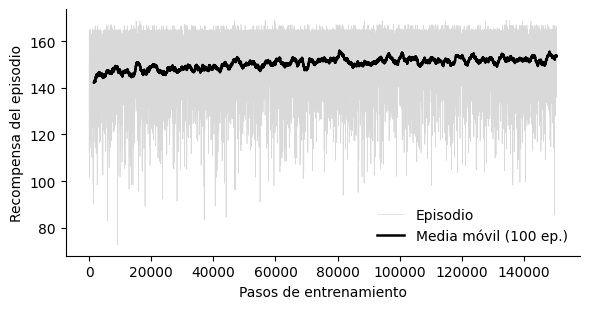

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
log = pd.read_csv("entrenamiento_v2.monitor.csv", skiprows=1)
log["paso"] = log["l"].cumsum()
log["mm"] = log["r"].rolling(100).mean()
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(log["paso"], log["r"], color="0.85", lw=0.5, label="Episodio")
ax.plot(log["paso"], log["mm"], color="black", lw=1.8, label="Media móvil (100 ep.)")
ax.set_xlabel("Pasos de entrenamiento"); ax.set_ylabel("Recompensa del episodio")
ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False)
fig.tight_layout(); fig.savefig("figura1_curva_v2.pdf"); fig.savefig("figura1_curva_v2.png", dpi=200)
plt.show()


### B.4 — Evaluación: Tabla I (150 escenarios de prueba, semillas 30000–30149)

In [12]:
from env2_turnos_horario import policy_static, policy_greedy, run_episode

def policy_ppo(env):
    a, _ = model.predict(env._obs(), action_masks=env.action_masks(), deterministic=True)
    return int(a)

ev = TurnosHorarioEnv(scenario="random")
POLS = {"Horario estático": policy_static, "Heurística voraz": policy_greedy,
        "Agente (PPO)": policy_ppo}
filas, crudos = {}, {}
for nombre, pol in POLS.items():
    rs = [run_episode(ev, pol, seed=30_000 + i) for i in range(150)]
    crudos[nombre] = [r["reward"] for r in rs]
    filas[nombre] = dict(rw=np.mean(crudos[nombre]), sd=np.std(crudos[nombre]),
                         gaps=np.mean([r["gaps"] for r in rs]),
                         ot=np.mean([r["overtime_drivers"] for r in rs]),
                         sig=np.mean([r["hours_std"] for r in rs]))
print(f"{'Política':<18}{'Recompensa':>16}{'Huecos':>8}{'H.ex':>7}{'σ':>7}")
for n, f in filas.items():
    print(f"{n:<18}{f['rw']:>9.1f} ± {f['sd']:<4.1f}{f['gaps']:>8.2f}{f['ot']:>7.2f}{f['sig']:>7.2f}")
g, p = np.array(crudos["Heurística voraz"]), np.array(crudos["Agente (PPO)"])
print(f"\nPPO vs voraz: gana {np.mean(p>g)*100:.0f}% | empata {np.mean(p==g)*100:.0f}% | pierde {np.mean(p<g)*100:.0f}%")
print("\nFilas LaTeX para la Tabla I:")
for n, f in filas.items():
    print(f"{n} & ${f['rw']:.1f} \\pm {f['sd']:.1f}$ & {f['gaps']:.2f} & {f['ot']:.2f} & {f['sig']:.2f} \\\\")


Política                Recompensa  Huecos   H.ex      σ
Horario estático      129.9 ± 22.7    5.08   0.00   1.32
Heurística voraz      152.5 ± 13.4    1.09   1.65   1.60
Agente (PPO)          152.7 ± 13.4    1.04   1.63   1.59

PPO vs voraz: gana 32% | empata 52% | pierde 16%

Filas LaTeX para la Tabla I:
Horario estático & $129.9 \pm 22.7$ & 5.08 & 0.00 & 1.32 \\
Heurística voraz & $152.5 \pm 13.4$ & 1.09 & 1.65 & 1.60 \\
Agente (PPO) & $152.7 \pm 13.4$ & 1.04 & 1.63 & 1.59 \\


### B.5 — Export de trayectorias para la demo (`hoja_despacho_v2.html`)
Genera `episodio_demo_v2.json` con las trayectorias reales de ambas políticas sobre el escenario fijo. Para episodios nuevos: cambia `scenario="random"` y pasa una semilla a `run_episode`.

In [13]:
import json
from env2_turnos_horario import HOURS, N_D, N_B, N_B_ACTIVE

def pack(policy):
    env = TurnosHorarioEnv(scenario="fixed")
    r = run_episode(env, policy)
    return {"summary": {k: r[k] for k in ("reward","gaps","overtime_drivers",
                                          "hours_std","driver_hours","bus_hours")},
            "events": r["log"]["events"], "steps": r["log"]["steps"]}

data = {"meta": {"scenario": "fixed-v2", "routes": ["A","B","C"], "hours": HOURS,
                 "n_ticks": 12, "drivers": [f"C{i+1:02d}" for i in range(N_D)],
                 "buses": [f"B-{i+1:02d}" for i in range(N_B)], "reserve_from": N_B_ACTIVE,
                 "modelo": f"MaskablePPO v2 horario {PASOS} pasos"},
        "policies": {"baseline": pack(policy_static), "agente": pack(policy_ppo)}}
json.dump(data, open("episodio_demo_v2.json","w",encoding="utf-8"), ensure_ascii=False)
print("baseline:", {k: data["policies"]["baseline"]["summary"][k] for k in ("reward","gaps")})
print("agente  :", {k: data["policies"]["agente"]["summary"][k] for k in ("reward","gaps")})


baseline: {'reward': 115.39, 'gaps': 8}
agente  : {'reward': 144.85, 'gaps': 2}


---
**Respaldo antes de cerrar la sesión** (Colab borra el disco local):
```python
from google.colab import drive
drive.mount('/content/drive')
!cp ppo_v2_horario.zip figura1_curva_v2.* episodio_demo_v2.json entrenamiento_v2.monitor.csv /content/drive/MyDrive/
```